In [1]:
import numpy as np
import scipy.linalg as scp
import matplotlib.pylab as plt
import time

import scipy.sparse as sps
import scipy.sparse.linalg as spla
from scipy.optimize import brentq
from types import SimpleNamespace
import scipy.integrate as scpi
from scipy.interpolate import interp1d
from scipy.integrate import trapezoid as trapz
import pandas as pd

from threedellips_morison import Beam3DMatrices, AddMooringSpringsGlobal
from spatial_convergence_full_model import wave_number_scalar, setup_jonswap, run_convergence_study, FEMsolver_snapshot, FEMsolver_full_transient, print_convergence_table

from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6
pass

  JONSWAP Hm0 check: 2.965 m  (target 2.965 m)

[snapshot] Lele=25.00 m  →  1080 elements, t_snap=500.0 s
  → solved in 2.8 s, |u_y|_max = 2.4091e+02 m, |u_z|_max = 1.9853e+01 m

[snapshot] Lele=12.50 m  →  2160 elements, t_snap=500.0 s
  → solved in 5.5 s, |u_y|_max = 2.4091e+02 m, |u_z|_max = 1.9853e+01 m

[snapshot] Lele=5.00 m  →  5400 elements, t_snap=500.0 s
  → solved in 13.3 s, |u_y|_max = 2.4091e+02 m, |u_z|_max = 1.9853e+01 m

[snapshot] Lele=2.50 m  →  10800 elements, t_snap=500.0 s
  → solved in 26.1 s, |u_y|_max = 2.4091e+02 m, |u_z|_max = 1.9853e+01 m


    Lele [m]     nEle      u_y_ref [m]      u_z_ref [m]
        25.0     1080    -2.304431e+02    -1.865476e+01
        12.5     2160    -2.304431e+02    -1.865476e+01
         5.0     5400    -2.304430e+02    -1.865475e+01
         2.5    10800    -2.304460e+02    -1.865470e+01


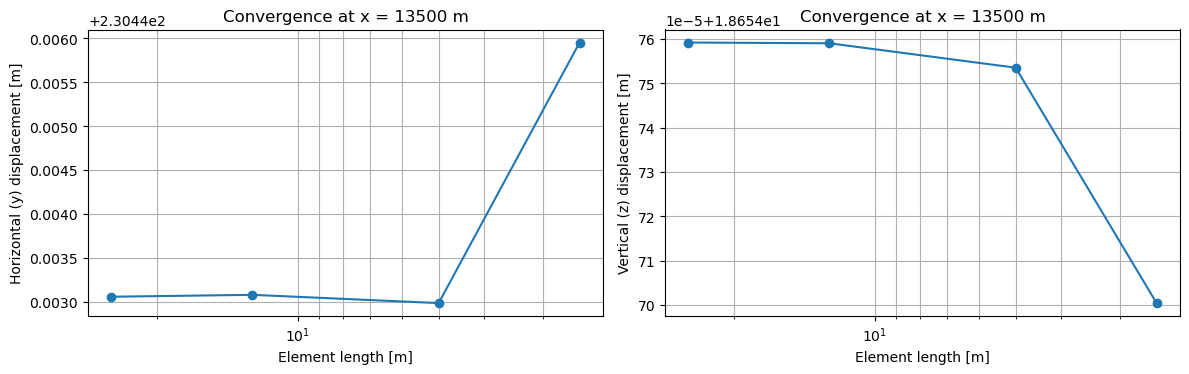

In [5]:
# ── Material / section constants (copy from your notebook) ───────────────
E = 40e9;  G = 12e9
L_tunnel = 27000.0;  z_tun = -27.5
mooring_spacing = 25.0
mass = 266.63e3;  Atot = 104.6242421
Iy = 3256.17;  Iz = 5950.91
ao = 14;  ai = 13;  bo = 8.5;  bi = 7.5
Im = ((ao*bo*(ao**2+bo**2) - ai*bi*(ai**2+bi**2))
    / (4*(ao*bo - ai*bi)))
Beam_EIy = E*Iy;  Beam_EIz = E*Iz
Beam_EA  = E*Atot
J = Iy + Iz;  Beam_GJ = G*J
ky = 2.03e6;  kz = 10.6e6;  kyz = kzy = 0.102e6
CD_y = 0.5;  CD_z = 1.5
rho_w = 1025.0;  g = 9.81;  d = 80.0

Hmo = 2.965;  Tp = 8.06;  gamma = 3.3
omega_p = 2.0*np.pi/Tp
k_wave = wave_number_scalar(omega_p, d)
a_surface_amp = Hmo/2.0
a_y_peak = a_surface_amp * np.cosh(k_wave*(d+z_tun)) / np.sinh(k_wave*d)
a_z_peak = a_surface_amp * np.sinh(k_wave*(d+z_tun)) / np.sinh(k_wave*d)
a_tunnel_amp = np.sqrt(0.5*(a_y_peak**2 + a_z_peak**2))

# ── Pre-compute wave field once ───────────────────────────────────────────
wave_params = setup_jonswap(Hmo, Tp, d, z_tun, gamma=gamma)

# ── Common kwargs for the solver ─────────────────────────────────────────
common = dict(
    L_tunnel=L_tunnel, E=E, G=G, mooring_spacing=mooring_spacing,
    Beam_EA=Beam_EA, Beam_EIy=Beam_EIy, Beam_EIz=Beam_EIz,
    Beam_GJ=Beam_GJ, mass=mass, Im=Im, Atot=Atot,
    ky=ky, kz=kz, kyz=kyz, kzy=kzy,
    ao=ao, ai=ai, bo=bo, bi=bi,
    rho_w=rho_w, CD_y=CD_y, CD_z=CD_z,
    a_tunnel_amp=a_tunnel_amp, omega_ref=omega_p,
    z_tun=z_tun,
    wave_params=wave_params,
    t_snap=500.0,    # well past ramp; change as needed
    )

# ── Convergence study ────────────────────────────────────────────────────
element_lengths = [25, 12.5, 5, 2.5]

results, summary = run_convergence_study(
    element_lengths=element_lengths,
    solver_func=FEMsolver_snapshot,
    common_kwargs=common,
    )

print_convergence_table(summary)

# ── Plot ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, key, label in zip(axes,
                               ['u_y_ref', 'u_z_ref'],
                               ['Horizontal (y) displacement [m]',
                                'Vertical (z) displacement [m]']):
        ax.semilogx(summary['Lele'], np.abs(summary[key]), 'o-')
        ax.set_xlabel('Element length [m]')
        ax.set_ylabel(label)
        ax.set_title(f'Convergence at x = {summary["x_ref_frac"]*L_tunnel:.0f} m')
        ax.invert_xaxis()
        ax.grid(True, which='both')
plt.tight_layout()
plt.savefig('convergence_plot.png', dpi=150)
plt.show()

In [3]:
# # ── Common kwargs for the solver ─────────────────────────────────────────
# common = dict(
#     L_tunnel=L_tunnel, E=E, G=G, mooring_spacing=mooring_spacing,
#     Beam_EA=Beam_EA, Beam_EIy=Beam_EIy, Beam_EIz=Beam_EIz,
#     Beam_GJ=Beam_GJ, mass=mass, Im=Im, Atot=Atot,
#     ky=ky, kz=kz, kyz=kyz, kzy=kzy,
#     ao=ao, ai=ai, bo=bo, bi=bi,
#     rho_w=rho_w, CD_y=CD_y, CD_z=CD_z,
#     a_tunnel_amp=a_tunnel_amp, omega_ref=omega_p,
#     z_tun=z_tun,
#     wave_params=wave_params,
#     t_0=0.0, dt=0.1,
#     n_jonswap=50, t_ramp=400.0,
#     rtol=1e-4, atol=1e-6
#     )

# # ── Convergence study ────────────────────────────────────────────────────
# element_lengths = [25, 12.5, 5, 2.5]

# results, summary = run_convergence_study(
#     element_lengths=element_lengths,
#     solver_func=FEMsolver_full_transient,
#     common_kwargs=common,
#     )

# print_convergence_table(summary)

# # ── Plot ─────────────────────────────────────────────────────────────────
# fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# for ax, key, label in zip(axes,
#                                ['u_y_ref', 'u_z_ref'],
#                                ['Horizontal (y) displacement [m]',
#                                 'Vertical (z) displacement [m]']):
#     ax.semilogx(summary['Lele'], np.abs(summary[key]), 'o-')
#     ax.set_xlabel('Element length [m]')
#     ax.set_ylabel(label)
#     ax.set_title(f'Convergence at x = {summary["x_ref_frac"]*L_tunnel:.0f} m')
#     ax.invert_xaxis()
#     ax.grid(True, which='both')
#     plt.tight_layout()
#     plt.savefig('convergence_plot.png', dpi=150)
#     plt.show()